<div class="alert alert-block alert-success">
    <h1 align="center">Traffic-Signs Classification | CNN - Resnet</h1>
    <h3 align="center">Image Classification</h3>
    
<a href="https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign">
About Dataset
    </a>
</div>

<img src="https://previews.123rf.com/images/grafner/grafner1606/grafner160600026/61038877-wide-background-collage-of-many-road-sign-illustration.jpg"/>

<div style="
    background-color:#e6f9e6;
    border-left:6px solid #4caf50;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <h2 style="text-align: center; color: #007400; margin-top: 0;">
        Welcome to the Notebook! 
    </h2>
    <p style="margin-bottom:10px;text-align:justify;">
       In this project, we aim to compare the performance of a simple Convolutional Neural Network (CNN) trained from scratch with a pre-trained ResNet101V2 model on the German Traffic Sign Recognition Benchmark (GTSRB) dataset, in order to demonstrate the effectiveness and advantages of Transfer Learning in computer vision tasks. While the simple CNN must learn all features from scratch, the pre-trained ResNet101V2 benefits from rich hierarchical features already learned on large-scale datasets like ImageNet. This comparison clearly shows how pre-trained models can achieve significantly higher accuracy with much less training time and data.
    </p>
</div>


<div style="
    background-color:#e6f9e6;
    border-left:6px solid #4caf50;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        About Dataset:
    </p>
    <p style="margin-bottom:10px;text-align:justify;">
       The German Traffic Sign Recognition Benchmark ( GTSRB ) is a widely used dataset for traffic sign classification tasks . It contains over 50,000 images of 43 different traffic sign categories , collected under various light , weather , and perspective conditions . Each image represents a real - world scenario with diverse scales and backgrounds , making it ideal for testing robustness in visual recognition models.
    </p>
</div>


<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1. Import Required Libraries
    </p>
</div>

In [2]:
import matplotlib.pyplot as plt
import random as rn
import numpy as np
import pandas as pd
import cv2 as cv
from tqdm.notebook import tqdm
from PIL import Image
#---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#---
from sklearn.metrics import accuracy_score
#---
import warnings
warnings.filterwarnings('ignore')

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1.1 Load Datasets:
    </p>
</div>

In [3]:
data_dir = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign'
meta_path = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Meta'
train_path = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train'
test_path = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test.csv'

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1.2 Class Labels Mapping
    </p>
</div>

In [4]:
classes = { 0:'Speed limit (20km/h)',
            1:'Speed limit (30km/h)',
            2:'Speed limit (50km/h)',
            3:'Speed limit (60km/h)',
            4:'Speed limit (70km/h)',
            5:'Speed limit (80km/h)',
            6:'End of speed limit (80km/h)',
            7:'Speed limit (100km/h)',
            8:'Speed limit (120km/h)',
            9:'No passing',
            10:'No passing veh over 3.5 tons',
            11:'Right-of-way at intersection',
            12:'Priority road',
            13:'Yield',
            14:'Stop',
            15:'No vehicles',
            16:'Veh > 3.5 tons prohibited',
            17:'No entry',
            18:'General caution',
            19:'Dangerous curve left',
            20:'Dangerous curve right',
            21:'Double curve',
            22:'Bumpy road',
            23:'Slippery road',
            24:'Road narrows on the right',
            25:'Road work',
            26:'Traffic signals',
            27:'Pedestrians',
            28:'Children crossing',
            29:'Bicycles crossing',
            30:'Beware of ice/snow',
            31:'Wild animals crossing',
            32:'End speed + passing limits',
            33:'Turn right ahead',
            34:'Turn left ahead',
            35:'Ahead only',
            36:'Go straight or right',
            37:'Go straight or left',
            38:'Keep right',
            39:'Keep left',
            40:'Roundabout mandatory',
            41:'End of no passing',
            42:'End no passing veh > 3.5 tons' }


<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        2. Data Preparation:
    </p>
</div>

In [5]:
batch_size = 32
seed = 42
width, height = 50 , 50

# Train And Validation set
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
X_train = train_datagen.flow_from_directory(directory=train_path,
                                            target_size=(width, height),
                                            seed=seed,
                                            subset='training',
                                            interpolation='hamming'
                                            )
X_validation = train_datagen.flow_from_directory(directory=train_path,
                                            target_size=(width, height),
                                            seed=seed,
                                            subset='validation',
                                            interpolation='hamming'
                                            )

# Test_set
def map_pred(pred):
    return [int(list(X_train.class_indices.keys())[i]) for i in pred]

X_test_df = pd.read_csv(data_dir+'/Test.csv')
X_test_labels = X_test_df.ClassId
imgs = X_test_df.Path

data=[]
for img in tqdm(imgs):
    try:
        image = cv.imread(data_dir+'/'+img)
        image_fromarray = Image.fromarray(image, 'RGB')
        final_image = image_fromarray.resize((width, height))
        data.append(final_image)
    except:
        print("Error in " + img)
X_test = np.array(data) /255

Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.


  0%|          | 0/12630 [00:00<?, ?it/s]

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Visualizing Dataset Samples
         </li>
        </ul>
</div>




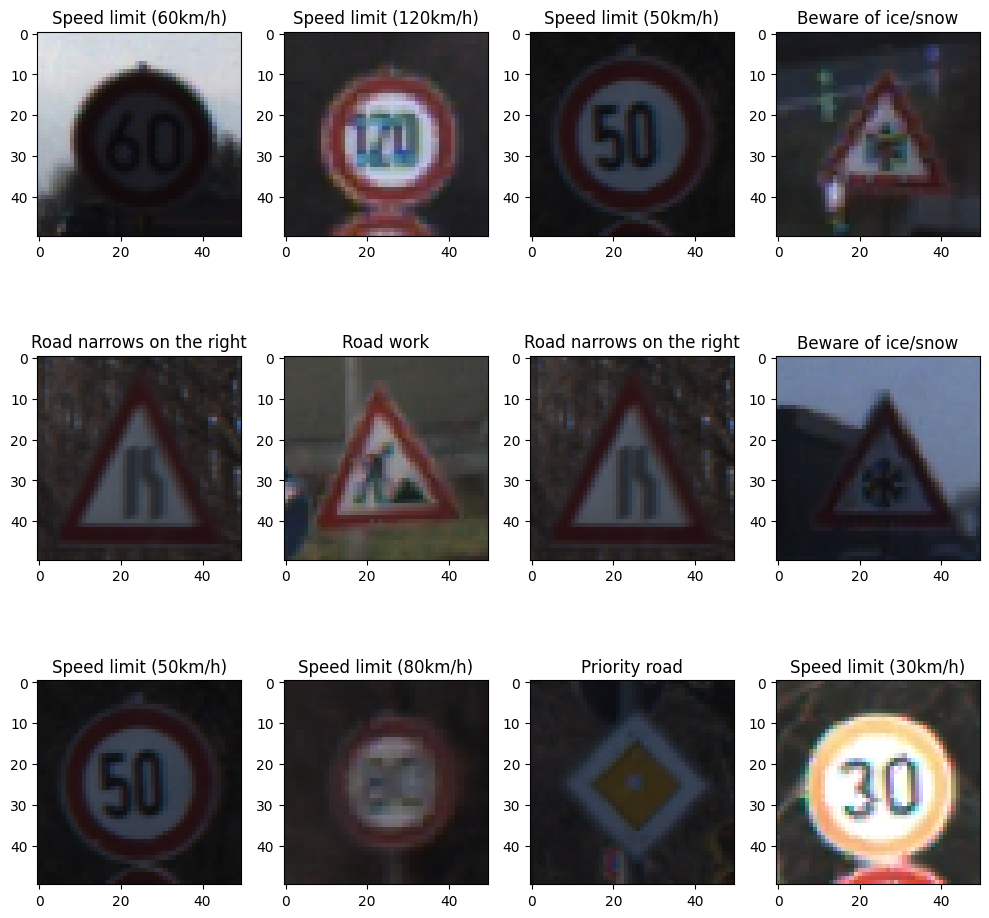

In [6]:
fig,ax=plt.subplots(3,4)
fig.set_size_inches(10,10)
img,y = next(X_train)
for i in range(3):
    for j in range (4):
        l = np.random.randint(0,batch_size)
        label = classes[int(list(X_train.class_indices.keys())[np.argmax(y[l])])]
        ax[i,j].imshow(img[l])
        ax[i,j].set_title(label)

plt.tight_layout()

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        3. Modeling
    </p>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Baseline Model: Simple CNN From Scratch 
         </li>
        </ul>
</div>

In [7]:
cnn_model = keras.models.Sequential([
    keras.layers.Input(shape=(width, height, 3)),
    #---
    keras.layers.Conv2D(filters=16, kernel_size=5, use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    #---
    keras.layers.Conv2D(filters=32, kernel_size=5, use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPool2D(),
    #---
    keras.layers.Conv2D(filters=64, kernel_size=3, use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    #---
    keras.layers.Conv2D(filters=128, kernel_size=3, use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPool2D(),
    #---
    keras.layers.Flatten(),
    keras.layers.Dense(units=512, use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(43, activation='softmax')
])

I0000 00:00:1781100698.155093      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781100698.161497      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
       CNN_Model Summary:
    </p>
</div>


In [8]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 16)     │         1,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 46, 46, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 42, 42, 32)     │        12,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 42, 42, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 42, 42, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 21, 21, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 19, 19, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 19, 19, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 19, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 17, 17, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 17, 17, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,325,531 (16.50 MB)

 Trainable params: 4,324,027 (16.49 MB)

 Non-trainable params: 1,504 (5.88 KB)

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Compile And Fit CNN_Model
         </li>
        </ul>
</div>

In [9]:
#compile:
cnn_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

#--callbacks:
# early_stopping = keras.callbacks.EarlyStopping(patience=10)
# per_lr = keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5)

#--model fit
history = cnn_model.fit(x=X_train,
                        steps_per_epoch=len(X_train),
                        validation_data=X_validation,
                        validation_steps=len(X_validation),
                        epochs=15)

Epoch 1/15


I0000 00:00:1781100703.141361     146 service.cc:152] XLA service 0x1a22f330 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781100703.141400     146 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781100703.141404     146 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781100703.755882     146 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/981 ━━━━━━━━━━━━━━━━━━━━ 1:19 82ms/step - accuracy: 0.0382 - loss: 4.4526     

I0000 00:00:1781100708.566949     146 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


981/981 ━━━━━━━━━━━━━━━━━━━━ 217s 213ms/step - accuracy: 0.9412 - loss: 0.2334 - val_accuracy: 0.9531 - val_loss: 0.1621
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - accuracy: 0.9932 - loss: 0.0278 - val_accuracy: 0.9406 - val_loss: 0.2063
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step - accuracy: 0.9939 - loss: 0.0214 - val_accuracy: 0.9663 - val_loss: 0.1163
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 48s 49ms/step - accuracy: 0.9962 - loss: 0.0131 - val_accuracy: 0.9202 - val_loss: 0.3320
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 47s 48ms/step - accuracy: 0.9945 - loss: 0.0165 - val_accuracy: 0.9282 - val_loss: 0.2382
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 47s 48ms/step - accuracy: 0.9961 - loss: 0.0120 - val_accuracy: 0.9705 - val_loss: 0.1010
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 46s 47ms/step - accuracy: 0.9964 - loss: 0.0109 - val_accuracy: 0.9352 - val_loss: 0.2802
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 43s 43ms/step - accuracy: 0.9972 - loss: 0.0094 - val_accur

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        CNN Model - Training History & Performance
    </p>
</div>


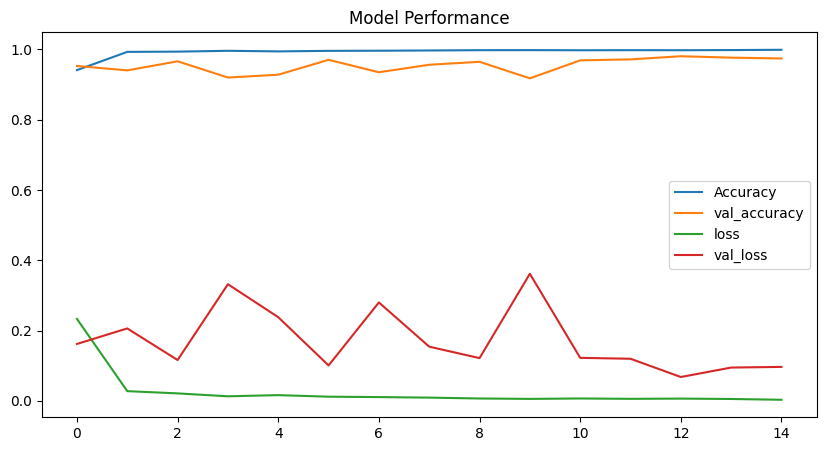

In [10]:
#print(history.history.keys())

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(history.history['accuracy'], label='Accuracy')
ax.plot(history.history['val_accuracy'], label='val_accuracy')
ax.plot(history.history['loss'], label='loss')
ax.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Performance')
plt.legend()
plt.show()

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       CNN Model - Evaluation on Test Set
         </li>
        </ul>
</div>

In [11]:
y_pred = cnn_model.predict(X_test)
y_pred = map_pred(y_pred.argmax(axis=1))
print('Test Accuracy: ', accuracy_score(X_test_labels, y_pred))

395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
Test Accuracy:  0.9182106096595408


<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Baseline CNN Model - Prediction Visualization on Test Images
    </p>
</div>

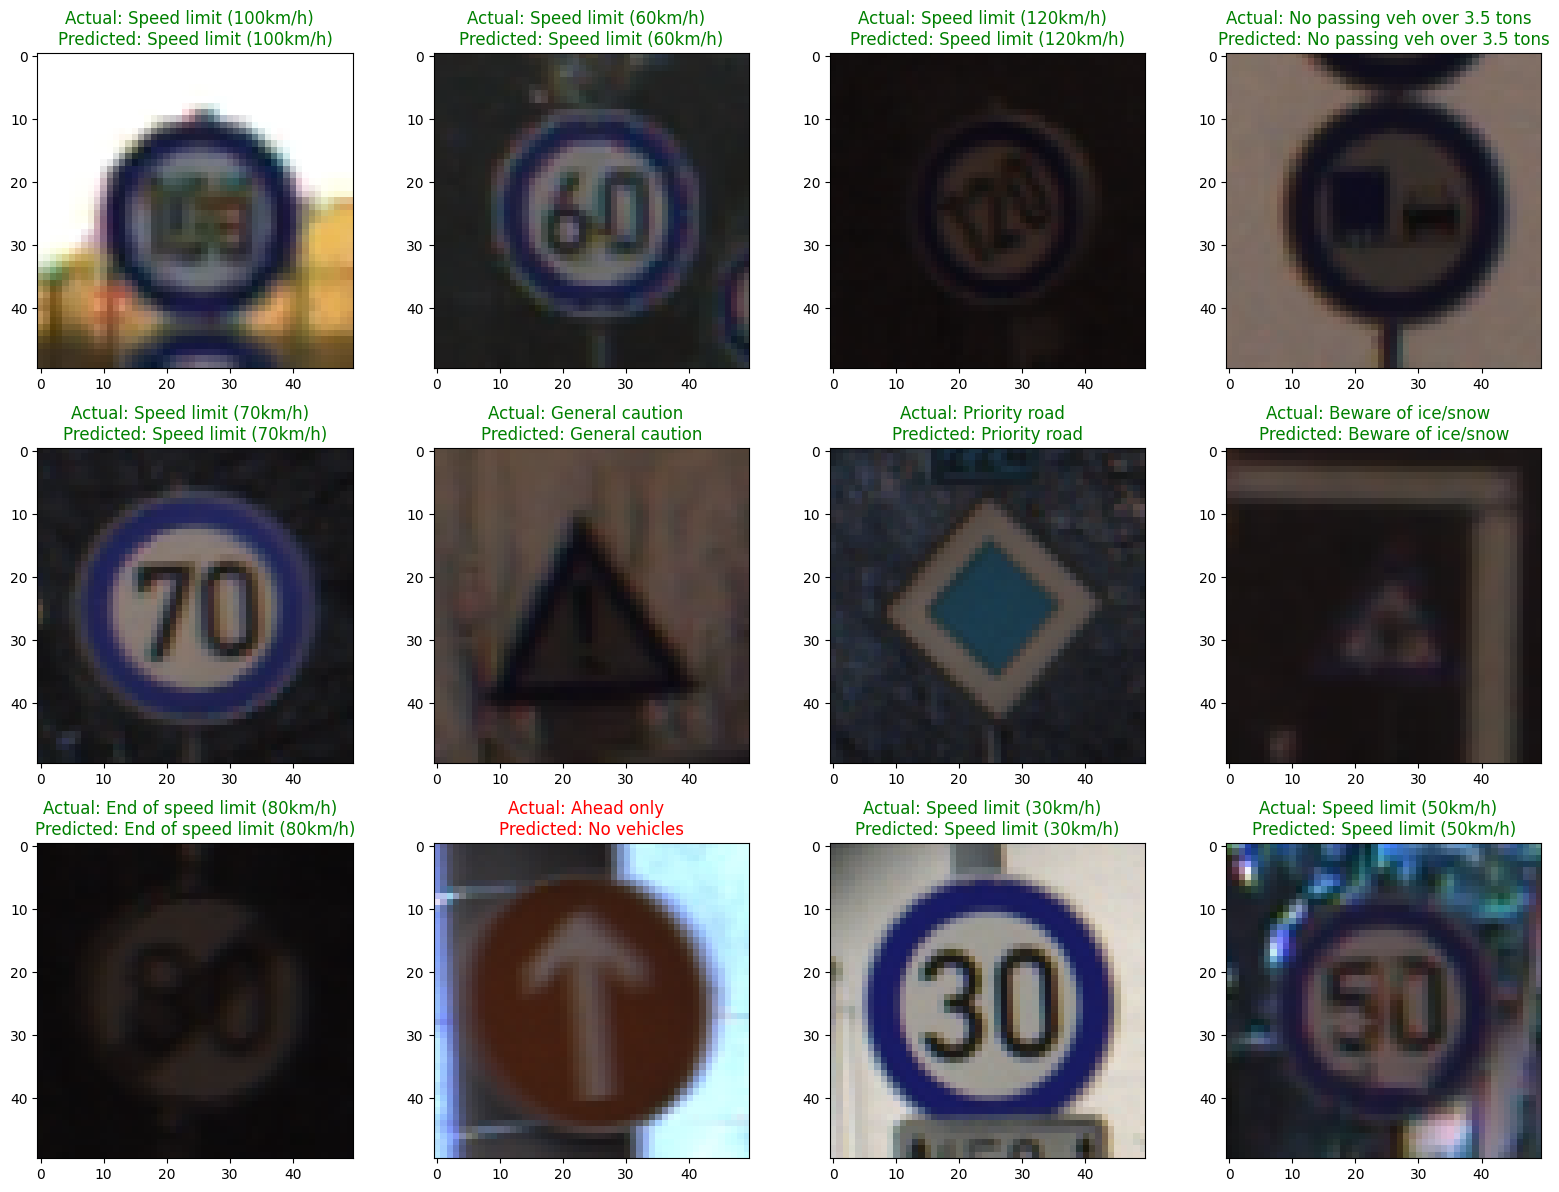

In [12]:
predicts = y_pred
labels = X_test_labels
fig,ax=plt.subplots(3,4)
fig.set_size_inches(16,12)
for i in range(3):
    for j in range (4):
        idx=np.random.randint(0,395)
        ax[i,j].imshow(X_test[idx])
        if labels[idx] == predicts[idx]:
            ax[i,j].set_title('Actual: '+classes[labels[idx]]+'  \nPredicted: '+classes[predicts[idx]], color = 'green')
        else:
            ax[i,j].set_title('Actual: '+classes[labels[idx]]+'  \nPredicted: '+classes[predicts[idx]], color = 'red')

plt.tight_layout()

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Save CNN Model:
    </p>
</div>


In [13]:
#cnn_model.save('Traffic_Sign_Classification_CNN_Model.keras')

<hr />

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Orginal Model: ResNet50V2 
         </li>
        </ul>
</div>

In [25]:
resnet = keras.applications.ResNet50V2(include_top=False, input_shape=(width, height, 3))
#---
x = keras.layers.BatchNormalization()(resnet.output)
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(512, activation='sigmoid')(x)
x = keras.layers.Dropout(0.3)(x)
output = keras.layers.Dense(43, activation='softmax')(x)
#---
resnet_model = keras.Model(inputs= resnet.input, outputs=output)

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Resnet Model Summary:
    </p>
</div>


In [15]:
resnet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 50, 50, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 56, 56, 3) │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 25, 25,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 27, 27,    │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 13, 13,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 13, 13,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 13, 13,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 13, 13,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 13, 13,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 13, 13,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 15, 15,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 13, 13,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 13, 13,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 13, 13,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 13, 13,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 13, 13,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 13, 13,    │          0 │ conv2_block1_0_c

 Total params: 27,789,867 (106.01 MB)

 Trainable params: 27,740,331 (105.82 MB)

 Non-trainable params: 49,536 (193.50 KB)

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Compile And Fit Resnet Model
         </li>
        </ul>
</div>

In [26]:
optimizer = keras.optimizers.Adam(learning_rate=0.0001)
#Compile:
resnet_model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
#Fit
resnet_history = resnet_model.fit(x=X_train,
                                  steps_per_epoch=len(X_train),
                                  validation_data=X_validation,
                                  validation_steps=len(X_validation),
                                  epochs=5, batch_size=-1)

Epoch 1/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 140s 94ms/step - accuracy: 0.8172 - loss: 0.6675 - val_accuracy: 0.9262 - val_loss: 0.2349
Epoch 2/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 59s 60ms/step - accuracy: 0.9843 - loss: 0.0556 - val_accuracy: 0.9389 - val_loss: 0.2351
Epoch 3/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 58s 59ms/step - accuracy: 0.9909 - loss: 0.0344 - val_accuracy: 0.9622 - val_loss: 0.1400
Epoch 4/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 58s 59ms/step - accuracy: 0.9938 - loss: 0.0240 - val_accuracy: 0.9643 - val_loss: 0.1424
Epoch 5/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 59s 60ms/step - accuracy: 0.9932 - loss: 0.0272 - val_accuracy: 0.9679 - val_loss: 0.1215


<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Resnet Model - Training History & Performance
    </p>
</div>


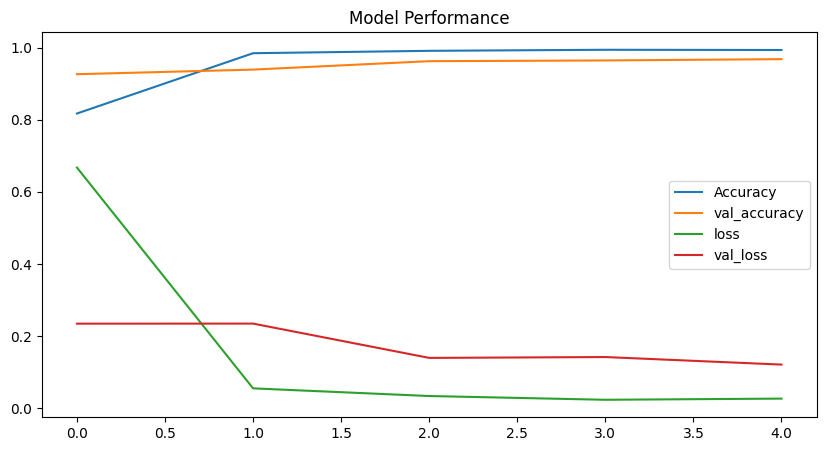

In [27]:
#print(history.history.keys())

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(resnet_history.history['accuracy'], label='Accuracy')
ax.plot(resnet_history.history['val_accuracy'], label='val_accuracy')
ax.plot(resnet_history.history['loss'], label='loss')
ax.plot(resnet_history.history['val_loss'], label='val_loss')
plt.title('Model Performance')
plt.legend()
plt.show()

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Resnet Model - Evaluation on Test Set
         </li>
        </ul>
</div>

In [28]:
y_pred = resnet_model.predict(X_test)
y_pred = map_pred(y_pred.argmax(axis=1))
print('Test Accuracy: ', accuracy_score(X_test_labels, y_pred))

395/395 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step
Test Accuracy:  0.9265241488519398


<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Resnet Model - Prediction Visualization on Test Images
    </p>
</div>

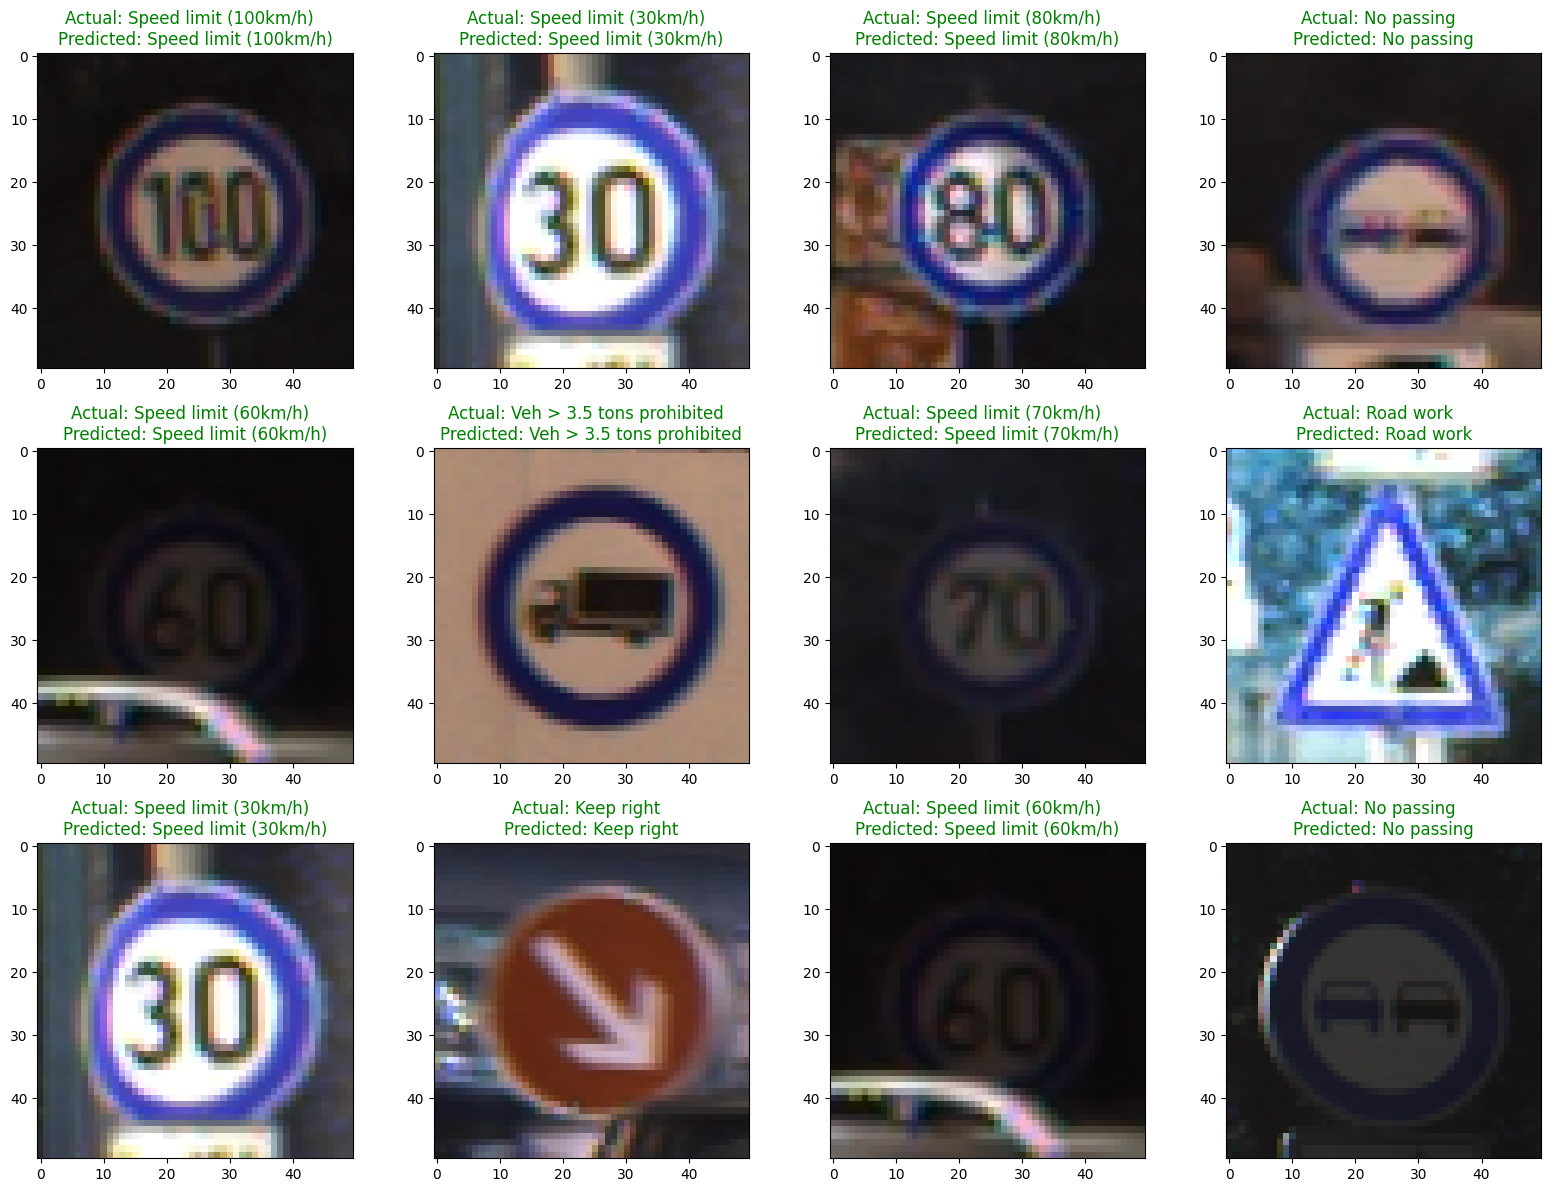

In [19]:
predicts = y_pred
labels = X_test_labels
fig,ax=plt.subplots(3,4)
fig.set_size_inches(16,12)
for i in range(3):
    for j in range (4):
        idx=np.random.randint(0,batch_size)
        ax[i,j].imshow(X_test[idx])
        if labels[idx] == predicts[idx]:
            ax[i,j].set_title('Actual: '+classes[labels[idx]]+'  \nPredicted: '+classes[predicts[idx]], color = 'green')
        else:
            ax[i,j].set_title('Actual: '+classes[labels[idx]]+'  \nPredicted: '+classes[predicts[idx]], color = 'red')

plt.tight_layout()

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Save Resnet Model:
    </p>
</div>


In [20]:
#resnet_model.save('ResNet50V2_model.keras')

<div
    style="
        background-color:#e6f9e6;
        border-left:6px solid #4caf50;
        padding: 20px;
        border-radius: 8px;
        margin: 20px 0;
        font-size: 16px;
        line-height: 1.6;
    "
>
    <h2 style="text-align: center; color: #4caf50; margin-top: 0;">
        Conclusion
    </h2>
    <p  style="margin-bottom:10px;text-align:justify;">
        In this experiment, we trained a simple CNN from scratch on a traffic sign dataset. After 15 epochs, it achieved a test accuracy of 91.82%.Then, we used a pre-trained ResNet50V2 model. With only 5 epochs – that’s just one‑third of the training time – it reached a test accuracy of 92.65%, even better than the custom CNN.
    </p>
    <p  style="margin-bottom:10px;text-align:justify;">
    This clearly shows the power of transfer learning. By starting from a model already trained on millions of images, we save significant time and computational resources. We don’t need to learn basic features like edges and shapes from zero. As a result, we get higher accuracy with less than half the epochs – and much faster training.
    </p>
    <p  style="margin-bottom:10px;text-align:justify;">
    So, if you have a small dataset or limited GPU time, transfer learning is not just a shortcut; it’s a smarter, more efficient path to better results.
    </p>
 <p  style="margin-bottom:10px;text-align:justify;font-weight:bold;">
 Thanks a lot for going through this notebook! I hope it was helpful and worth your time.
 </p>
</div>